In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import sklearn
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn.functional as F

from transformers import BertTokenizer, BertModel
from transformers import logging

In [2]:
# Import BERT tokenizer and model
logging.set_verbosity_error()

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
embeddings = model.embeddings.word_embeddings.weight.detach().numpy()
#

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

# Extract text and tokenize

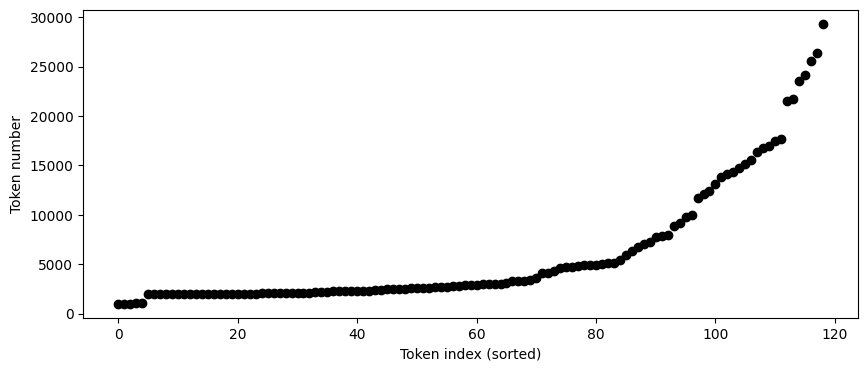

In [3]:
# https://en.wikipedia.org/wiki/Carbonated_water
text = "It is thought that the first person to aerate water with carbon dioxide was William Brownrigg in the 1740s. Joseph Priestley invented carbonated water, independently and by accident, in 1767 when he discovered a method of infusing water with carbon dioxide after having suspended a bowl of water above a beer vat at a brewery in Leeds, Yorkshire. He wrote of the 'peculiar satisfaction' he found in drinking it, and in 1772 he published a paper entitled Impregnating Water with Fixed Air. Priestley's apparatus, almost identical to that used by Henry Cavendish five years earlier, which featured a bladder between the generator and the absorption tank to regulate the flow of carbon dioxide, was soon joined by a wide range of others. However, it was not until 1781 that companies specialized in producing artificial mineral water were established and began producing carbonated water on a large scale. The first factory was built by Thomas Henry of Manchester, England. Henry replaced the bladder in Priestley's system with large bellows."

# https://en.wikipedia.org/wiki/Small-world_network
# text = "A small-world network is a graph characterized by a high clustering coefficient and low distances. In an example of the social network, high clustering implies the high probability that two friends of one person are friends themselves. The low distances, on the other hand, mean that there is a short chain of social connections between any two people (this effect is known as six degrees of separation). Specifically, a small-world network is defined to be a network where the typical distance L between two randomly chosen nodes (the number of steps required) grows proportionally to the logarithm of the number of nodes N in the network,"

# get all the unique tokens
tokens = tokenizer.encode(text, add_special_tokens=False)
tokens = np.sort(list(set( tokens )))


plt.figure(figsize=(10,4))
plt.plot(tokens,'ko')
plt.gca().set(xlabel='Token index (sorted)',ylabel='Token number')
plt.show()

# Cosine similarity of the embedding matrix

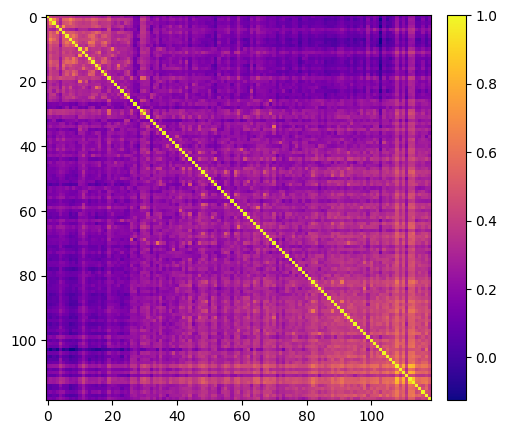

In [4]:
sc = cosine_similarity(embeddings[tokens])

# Plot the cosine similarity matrix
plt.figure(figsize=(10,5))
plt.imshow(sc,cmap='plasma')
plt.colorbar(pad=0.02)

plt.show()

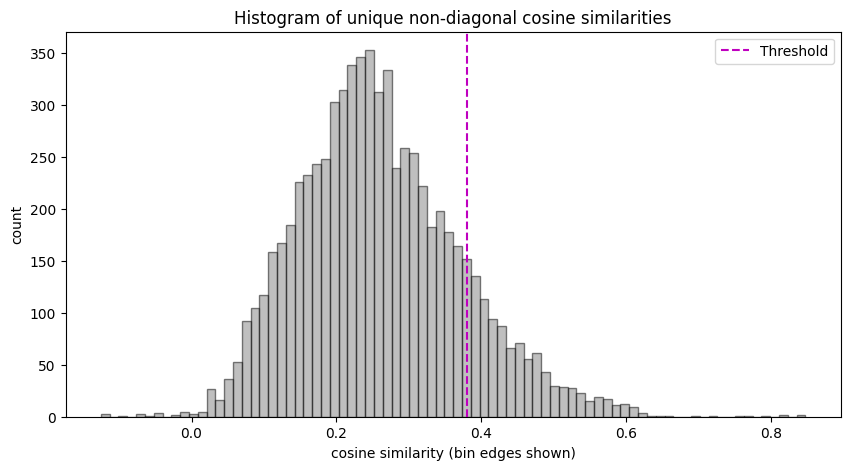

In [5]:
# Unique non-diagonal cosine similarities
bincount = 80
# tri = np.triu_indices_from(sc, k=1)
tri = np.nonzero(np.triu(sc,k=1))
vals = sc[tri]

# threshold to differentiate between higher and lower cosine similarity scores
thresh = np.median(vals) + np.std(sc)

# Compute histogram manually
counts, edges = np.histogram(vals, bins=bincount)

# Convert edges → bar centers and widths
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)

# Bar plot
plt.figure(figsize=(10,5))
plt.bar(centers, counts, width=widths, align='center', edgecolor='black', facecolor=[.5,.5,.5], alpha=.5)
plt.axvline(x=thresh, color='m', linestyle='--', label='Threshold')
plt.legend()

plt.xlabel("cosine similarity (bin edges shown)")
plt.ylabel("count")
plt.title("Histogram of unique non-diagonal cosine similarities")
plt.show()


# Create a mask for cosine matrix based on threshold values

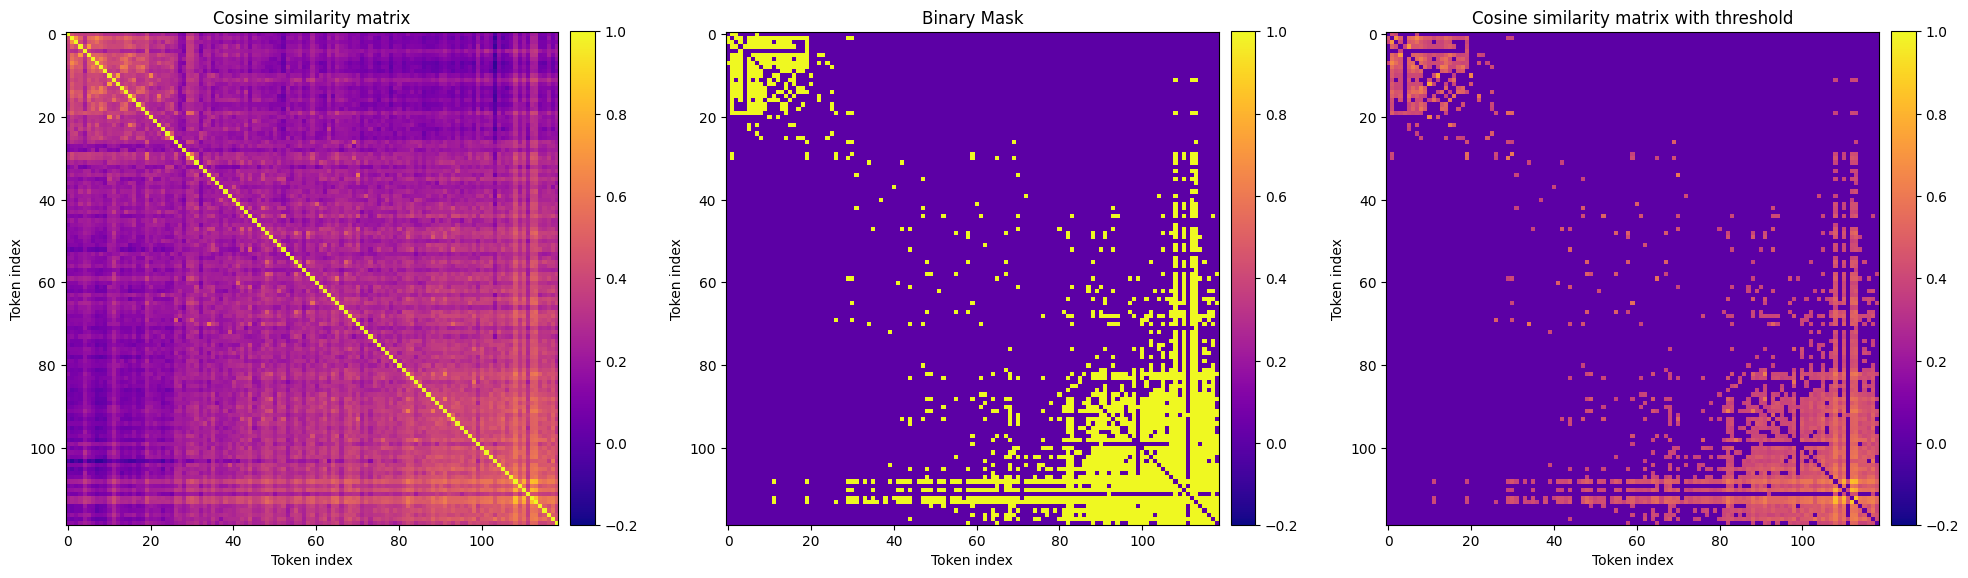

In [7]:
mask = sc > thresh
np.fill_diagonal(mask,0)

sc_masked = sc.copy()
sc_masked[sc<thresh] = 0

# fill the diagonal element with 0
np.fill_diagonal(sc_masked,0)

# Plot
_, axs = plt.subplots(1,3,figsize=(20,5.5))
im = axs[0].imshow(sc,cmap='plasma', vmin=-.2, vmax=1)
axs[0].set_title("Cosine similarity matrix")
axs[0].set_xlabel("Token index")
axs[0].set_ylabel("Token index")
plt.colorbar(im, ax=axs[0], pad=.02)

im = axs[1].imshow(mask,cmap='plasma', vmin=-.2, vmax=1)
axs[1].set_title("Binary Mask")
axs[1].set_xlabel("Token index")
axs[1].set_ylabel("Token index")
plt.colorbar(im, ax=axs[1], pad=.02)

im = axs[2].imshow(sc_masked,cmap='plasma', vmin=-.2, vmax=1)
axs[2].set_title("Cosine similarity matrix with threshold")
axs[2].set_xlabel("Token index")
axs[2].set_ylabel("Token index")
plt.colorbar(im, ax=axs[2], pad=.02)

plt.tight_layout()
plt.show()



# Create a graph for the cosine similarity matrix

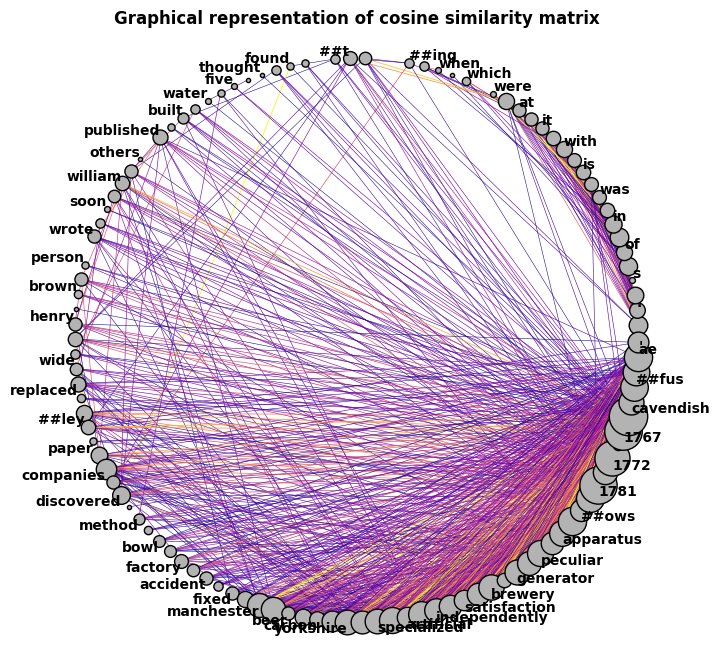

In [12]:
N = len(tokens)
offset = 1 / N
theta = np.linspace(0, 2*np.pi-offset, N)

# Create a figure
fig = plt.figure(figsize=(8,8))

for i in range(N):

  # Determine the marker size
  dotsize = 3 * np.sqrt(np.sum(mask[i]))

  if dotsize == 0: continue

  plt.plot(np.cos(theta[i]), np.sin(theta[i]), 'ko', markersize=dotsize, markerfacecolor=[.7,.7,.7])

  # Annotate the tokens at even idices
  if i % 2 == 0:
    plt.text(np.cos(theta[i]), np.sin(theta[i]), tokenizer.decode(tokens[i]),
             ha=['right', 'left'][int(np.cos(theta[i])>0)],
             va=['top', 'bottom'][int(np.sin(theta[i])>0)],
             fontweight='bold')

  # Loop over all the other tokens
  for j in range(i+1,N):

    # Draw a line if similarity exceeds the threshold
    if mask[i,j]:

      # colors by cosine similarity scores
      color = mpl.cm.plasma((sc[i,j]-thresh)/.2)

      # Plot the lines
      plt.plot([np.cos(theta[i]), np.cos(theta[j])],[np.sin(theta[i]), np.sin(theta[j])], color=color, linestyle='-', linewidth=sc[i,j], zorder=-19)


plt.title("Graphical representation of cosine similarity matrix", fontweight='bold')
plt.axis('equal')
plt.axis('off')
plt.show()
